# Phase 2 - Baseline Model Training

In [ ]:
# Public Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import sys

# Custom Imports
src_dir = Path("../src")
sys.path.insert(0, str(src_dir))

from data_preprocessing import load_data, resolve_project_root
from evaluate import *
from model import *
from train import save_model, set_global_seed, train_autoencoder

project_root = resolve_project_root()

# Set seed for reproducibility
set_global_seed(42)

# Create models directory if it doesn't exist
models_dir = project_root / "models"

# Define paths for data and models
data_dir = project_root / "data" / "processed"

## Load Training and Test Data

In [76]:
# Load train and test tables
train_data_path = data_dir / "train.csv"
test_data_path = data_dir / "test.csv"

train_set = load_data(train_data_path)
test_set = load_data(test_data_path)

print("Train Set:")
display(train_set.head())
print("Test Set:")
display(test_set.head())

# Convert labels to numeric classes expected by sklearn metrics
label_to_int = {"normal": 0, "anomaly": 1}

feature_cols = [c for c in train_set.columns if c not in ["label", "binary_label"]]
X_train_df = train_set[feature_cols]
X_test_df = test_set[feature_cols]

y_train_series = train_set["binary_label"].map(label_to_int)
y_test_series = test_set["binary_label"].map(label_to_int)

if y_train_series.isna().any() or y_test_series.isna().any():
    raise ValueError("Unexpected values found in binary_label. Expected only 'normal' and 'anomaly'.")

# Default source: arrays built from CSV
X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)
y_train = y_train_series.to_numpy(dtype=np.int32)
y_test = y_test_series.to_numpy(dtype=np.int32)
source = "CSV-derived arrays"

print(f"Train Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Test Set Shape: {X_test.shape}, Labels Shape: {y_test.shape}")

Train Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.026526,-0.092098,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
1,-0.145561,-0.026472,-0.051431,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
2,-0.145561,-0.026689,-0.086207,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
3,-0.145561,-0.026173,-0.066131,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.025901,0.015446,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False


Test Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
1,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
2,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,True,False,False,False,False,False,False,False,False,False
3,-0.145561,-0.029163,-0.080533,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False


Train Set Shape: (61482, 118), Labels Shape: (61482,)
Test Set Shape: (84104, 118), Labels Shape: (84104,)


## Model Architecture Setup (2.1)

In [77]:
# Develop functions here (Finsihed function go into the .py files in the src folder)

In [ ]:
# Shared model definition comes from src.model.
model = Autoencoder(input_dim=X_train.shape[1], latent_dim=16)

In [79]:
# Initialize the model
model  = Autoencoder(input_dim = X_train.shape[1], latent_dim = 16)

## Train Tool Implementation (2.2)

In [80]:
# Develop functions here (Finsihed function go into the .py files in the src folder)

In [ ]:
# Train the model using the shared training helper so seeding and device selection stay centralized.
model, history = train_autoencoder(
    X_train,
    input_dim=X_train.shape[1],
    latent_dim=16,
    epochs=50,
    batch_size=256,
    seed=42,
)

# Save the model
print("Saving the model...")
save_model(model, models_dir / "autoencoder_baseline_model.keras")
print("Final model saved!")

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 610us/step - loss: 0.2140
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - loss: 0.1196
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 0.0904
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - loss: 0.0750
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 0.0617
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 0.0524
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - loss: 0.0463
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.0414
Epoch 9/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 0.0366
Epoch 10/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - loss: 0.0330
Epoch 11/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 0.0304
Epoch 12/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.0285
Epoch 13/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - loss: 0.0264
Epoch 14/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - loss: 0.0252
Epoch 15/50
241/241 ━━━━━━━━━

## Baseline Training & Anomaly Thresholding (2.3)

In [ ]:
from evaluate import calculate_reconstruction_error, generate_anomaly_metrics_and_threshold

# Initialize Global Variables for model development
THRESHOLD_PERCENTILE = 95

# The shared evaluation helpers now live in src/evaluate.py.


A new final model has been trained in the notebook.


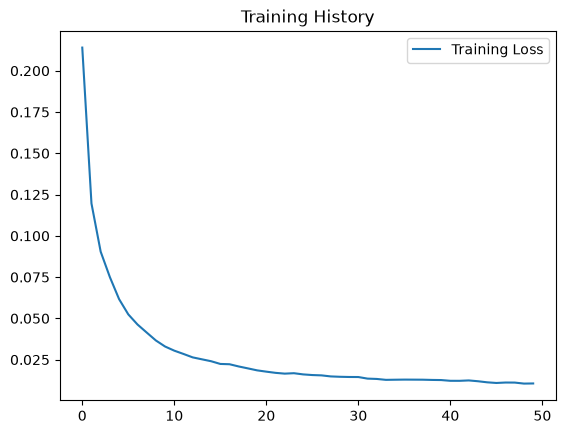


Final Model Summary:


Model: "autoencoder_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_14 (Sequential)      │ (None, 16)             │         4,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_15 (Sequential)      │ (None, 118)            │         4,438 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,324 (102.83 KB)

 Trainable params: 8,774 (34.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,550 (68.56 KB)

Generating anomaly metrics and threshold...

Train set Anomaly Threshold (Percentile 95): 0.0289



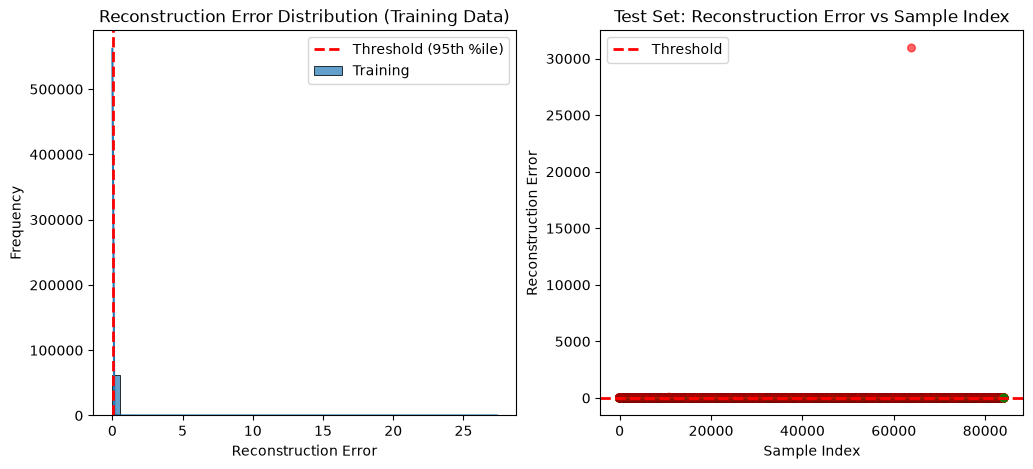

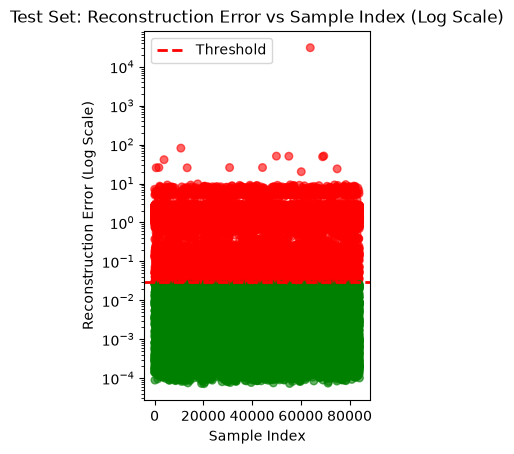

TEST SET EVALUATION METRICS
Accuracy: 0.9787

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     26350
           1       0.98      0.99      0.98     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.98     84104
weighted avg       0.98      0.98      0.98     84104

Confusion Matrix:
[[24969  1381]
 [  409 57345]]


In [ ]:
# Check if the final model has been trained in the notebook; otherwise load it from disk
if "model" not in locals() or model is None:
    print("Final model not found. Loading the best model from model directory...")
    model = keras.models.load_model(project_root / "models" / "autoencoder_baseline_model.keras")
else:
    print("A new final model has been trained in the notebook.")

# Plot available training history safely (if present)
if "history" in locals() and hasattr(history, "history"):
    if "loss" in history.history:
        plt.plot(history.history["loss"], label="Training Loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Training History")
    plt.legend()
    plt.show()

# Output the model summary for verification
print("\nFinal Model Summary:")
model.summary()

print("Generating anomaly metrics and threshold...\n")
threshold, y_pred, metrics = generate_anomaly_metrics_and_threshold(
    model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE
)
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1-score: {metrics['f1_score']:.4f}")